1. IMPORT THƯ VIỆN

In [1]:
!pip install pandas numpy matplotlib scikit-learn statsmodels pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

2. ĐỌC TỆP CSV

In [3]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/retail_store_inventory.csv"
df = pd.read_csv(file_path)

Mounted at /content/drive


In [4]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


3. TIỀN XỬ LÝ DỮ LIỆU

In [5]:
# Chuyển cột Date thành datetime và Sắp xếp
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Store ID', 'Product ID', 'Date'])

# Xử lý thiếu dữ liệu
df['Units Sold'] = df['Units Sold'].fillna(0)
df['Inventory Level'] = df['Inventory Level'].ffill()
df['Price'] = df['Price'].fillna(df['Price'].median())
df['Competitor Pricing'] = df['Competitor Pricing'].fillna(df['Competitor Pricing'].median())
df['Discount'] = df['Discount'].fillna(df['Discount'].median())
df['Demand Forecast'] = df['Demand Forecast'].fillna(df['Demand Forecast'].median())

# Xử lý ngoại lệ (Winsorize P1–P99)
df['Units Sold'] = winsorize(df['Units Sold'], limits=[0.01, 0.01])
df['Price'] = winsorize(df['Price'], limits=[0.01, 0.01])

# Xóa bản ghi trùng lặp
df = df.drop_duplicates()

4. CHỌN CHUỖI & CHUẨN BỊ DỮ LIỆU CHO SARIMAX

In [6]:
# Chọn 1 chuỗi cụ thể (Store, Product) có length >= 180d
store, product = df['Store ID'].iloc[0], df['Product ID'].iloc[0] # Đang chọn chuỗi đầu tiên
data = df[(df['Store ID'] == store) & (df['Product ID'] == product)].copy()

# Kiểm tra độ dài chuỗi
if len(data) < 180:
    print(f"Lỗi: Chuỗi {store}-{product} chỉ có {len(data)} ngày, cần >= 180 ngày. Vui lòng chọn chuỗi khác.")
    exit()

# Reindex theo ngày và Fill Units Sold
data = data.set_index('Date').asfreq('D')
data['Units Sold'] = data['Units Sold'].fillna(0) # Điền 0 cho Units Sold bị thiếu do reindex

# TẠO BIẾN LAG VÀ CALENDAR FEATURE
for lag in [1, 7, 14, 28]:
    data[f'lag_{lag}'] = data['Units Sold'].shift(lag)

data['dow'] = data.index.dayofweek
data['month'] = data.index.month
data['Holiday/Promotion'] = data['Holiday/Promotion'].ffill()
data = data.dropna(subset=['Units Sold']) # Đảm bảo target không có NA

5. CHIA TẬP TRAIN / VALIDATION / TEST (THEO THỜI GIAN)

In [7]:
train_size = int(len(data) * 0.7) # 70%
val_size = int(len(data) * 0.15)  # 15%
train_data = data.iloc[:train_size].copy()
val_data = data.iloc[train_size:train_size + val_size].copy()
test_data = data.iloc[train_size + val_size:].copy()

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Train: 511 | Val: 109 | Test: 111


7. XỬ LÝ BIẾN NGOẠI SINH (SCALE & ENCODE)

In [8]:
# Định nghĩa các cột ngoại sinh
exog_cat_cols = ['Weather Condition']
exog_num_cols = ['Price', 'Competitor Pricing', 'Discount', 'Demand Forecast']
exog_cal_cols = ['Holiday/Promotion', 'dow', 'month'] # Biến đã là số (0/1 hoặc int)

# Column Transformer: Fit trên Train, Transform trên Val/Test
ct = ColumnTransformer([
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), exog_cat_cols),
    ('scale', StandardScaler(), exog_num_cols)
], remainder='passthrough', n_jobs=-1, verbose_feature_names_out=False)

# Fit và Transform cho tập train
train_exog_transformed = ct.fit_transform(train_data[exog_cat_cols + exog_num_cols])
# Lấy tên cột sau one-hot và scale
feature_names = ct.get_feature_names_out()
train_exog_df = pd.DataFrame(train_exog_transformed, index=train_data.index, columns=feature_names)
train_exog_df[exog_cal_cols] = train_data[exog_cal_cols]

# Chỉ Transform cho tập val/test (Dùng FIT SCALER TỪ TRAIN)
val_exog_transformed = ct.transform(val_data[exog_cat_cols + exog_num_cols])
val_exog_df = pd.DataFrame(val_exog_transformed, index=val_data.index, columns=feature_names)
val_exog_df[exog_cal_cols] = val_data[exog_cal_cols]

 7. KIỂM TRA TÍNH DỪNG (ADF) VÀ TUNING (AUTO-ARIMA)

In [9]:
## KIỂM TRA TÍNH DỪNG (ADF)
adf_result = adfuller(train_data['Units Sold'])
d_term = 0
if adf_result[1] > 0.05:
    print(f"ADF p-value: {adf_result[1]:.4f} > 0.05. Chuỗi không dừng. Cần sai phân.")
    # Thử sai phân bậc 1
    adf_diff1 = adfuller(train_data['Units Sold'].diff().dropna())
    if adf_diff1[1] <= 0.05:
        d_term = 1
        print(f"ADF p-value sau sai phân bậc 1: {adf_diff1[1]:.4f}. Chọn d=1.")
    else:
        d_term = 2 # Nếu không dừng ở d=1 thì tăng lên 2
        print(f"ADF p-value sau sai phân bậc 1: {adf_diff1[1]:.4f} > 0.05. Chọn d=2.")
else:
    print(f"ADF p-value: {adf_result[1]:.4f} <= 0.05. Chuỗi là chuỗi dừng. Chọn d=0.")
    d_term = 0

## TUNING (Auto-ARIMA theo AICc)
print("\nBắt đầu tìm kiếm tham số tối ưu với auto_arima (AICc)...")
# Giới hạn d theo kết quả ADF để tăng tốc độ và độ chính xác
auto_model = auto_arima(
    train_data['Units Sold'],
    exogenous=train_exog_df,
    seasonal=True,
    m=7, # Mùa vụ tuần s=7
    d=d_term, # Bậc d cố định từ ADF
    start_p=0, start_q=0,
    max_p=2, max_d=2, max_q=2,
    max_P=2, max_D=1, max_Q=2,
    information_criterion='aicc',
    stepwise=True,
    trace=True # Đặt True nếu muốn xem quá trình tìm kiếm
)

best_order = auto_model.order
best_seasonal_order = auto_model.seasonal_order
print(f"SARIMAX Best Order: {best_order} x {best_seasonal_order}_7 (AICc: {auto_model.aic():.2f})")

ADF p-value: 0.0000 <= 0.05. Chuỗi là chuỗi dừng. Chọn d=0.

Bắt đầu tìm kiếm tham số tối ưu với auto_arima (AICc)...
Performing stepwise search to minimize aicc
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AICC=6241.019, Time=0.50 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AICC=6237.218, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AICC=6241.039, Time=0.13 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AICC=6240.937, Time=0.19 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AICC=6730.000, Time=0.01 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AICC=6239.144, Time=0.06 sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AICC=6238.988, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AICC=6239.168, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AICC=6239.173, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[7] intercept   : AICC=6241.206, Time=0.06 sec

Best model:  ARIMA(0,0,0)(0,0,0)[7] intercept
Total fit time: 1.099 seconds
SARIMAX Best Order: (0, 0, 0) x (0, 0, 0, 7)_7 (AICc: 6237.19)


 8. HUẤN LUYỆN MÔ HÌNH SARIMAX TỐI ƯU

In [10]:
print("\nBẮT ĐẦU HUẤN LUYỆN MÔ HÌNH SARIMAX...")
model = SARIMAX(
    train_data['Units Sold'],
    exog=train_exog_df,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend='c', # Thử trend='c' (constant) hoặc 'n' (none)
    enforce_stationarity=False,
    enforce_invertibility=False
)
result = model.fit(disp=False)
print(result.summary())


BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH SARIMAX...
                               SARIMAX Results                                
Dep. Variable:             Units Sold   No. Observations:                  511
Model:                        SARIMAX   Log Likelihood               -1812.293
Date:                Tue, 25 Nov 2025   AIC                           3650.586
Time:                        12:43:14   BIC                           3705.634
Sample:                    01-01-2022   HQIC                          3672.168
                         - 05-26-2023                                         
Covariance Type:                  opg                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
intercept                    0.0032      0.817      0.004      0.997      -1.597       1.604
Weather Condition_Cloudy   137.5011      0.662    

9. DỰ BÁO VÀ ĐÁNH GIÁ (Validation)

In [11]:
print("\n================== DỰ BÁO VÀ ĐÁNH GIÁ ==================")

## Tính Naive-7 Baseline
# Lưu ý: 'val_data' đã là bản sao độc lập (copy()) từ bước chia dữ liệu
val_data['Units Sold Shifted'] = val_data['Units Sold'].shift(7)
# Để tính Naive-7, cần dùng dữ liệu từ train để dự báo 7 ngày đầu của val
# Lấy 7 ngày cuối của train
last_7_train = train_data['Units Sold'].iloc[-7:]
# Ghép lại để shift 7 ngày
full_series = pd.concat([last_7_train, val_data['Units Sold']])
val_data['Naive_7_pred'] = full_series.shift(7).iloc[len(last_7_train):]
val_data_for_metrics = val_data.dropna(subset=['Naive_7_pred'])

# Metric Naive-7
rmse_naive = np.sqrt(mean_squared_error(val_data_for_metrics['Units Sold'], val_data_for_metrics['Naive_7_pred']))
wape_naive = np.sum(np.abs(val_data_for_metrics['Units Sold'] - val_data_for_metrics['Naive_7_pred'])) / np.sum(val_data_for_metrics['Units Sold'])

print(f"--- Naive-7 Baseline ---")
print(f"RMSE Naive-7: {rmse_naive:.3f}, WAPE Naive-7: {wape_naive:.3%}")

## Dự báo SARIMAX
forecast = result.get_forecast(steps=len(val_data), exog=val_exog_df)
pred_mean = forecast.predicted_mean
pred_ci = forecast.conf_int()

# Đánh giá SARIMAX
rmse_sarimax = np.sqrt(mean_squared_error(val_data['Units Sold'], pred_mean))
wape_sarimax = np.sum(np.abs(val_data['Units Sold'] - pred_mean)) / np.sum(val_data['Units Sold'])

print(f"\n--- SARIMAX Model ---")
print(f"RMSE SARIMAX: {rmse_sarimax:.3f}, WAPE SARIMAX: {wape_sarimax:.3%}")

# So sánh tương đối với Baseline
rmse_ratio = rmse_sarimax / rmse_naive
wape_improvement = (wape_naive - wape_sarimax) / wape_naive

print(f"\n--- So sánh tương đối với Naive-7 ---")
print(rf"RMSE Ratio (SARIMAX/Naive-7): {rmse_ratio:.2f} (Yêu cầu <= 0.85?)")
if rmse_ratio <= 0.85:
    print(r"-> ĐẠT yêu cầu RMSE tương đối!")
else:
    print(r"-> CHƯA ĐẠT yêu cầu RMSE tương đối <= 0.85!")
print(rf"WAPE Improvement: {wape_improvement:.1%} (Kỳ vọng >= 10-20%))")


================== DỰ BÁO VÀ ĐÁNH GIÁ ==================
--- Naive-7 Baseline ---
RMSE Naive-7: 148.948, WAPE Naive-7: 86.374%

--- SARIMAX Model ---
RMSE SARIMAX: 9.215, WAPE SARIMAX: 5.959%

--- So sánh tương đối với Naive-7 ---
RMSE Ratio (SARIMAX/Naive-7): 0.06 (Yêu cầu <= 0.85?)
-> ĐẠT yêu cầu RMSE tương đối!
WAPE Improvement: 93.1% (Kỳ vọng >= 10-20%))


10. KIỂM TRA CHẨN ĐOÁN (DIAGNOSTICS)


Ljung–Box Test (p-value > 0.05 là tốt):
      lb_stat  lb_pvalue
10  16.536406   0.085272
20  23.898860   0.246838
-> Residuals gần giống White Noise. OK.


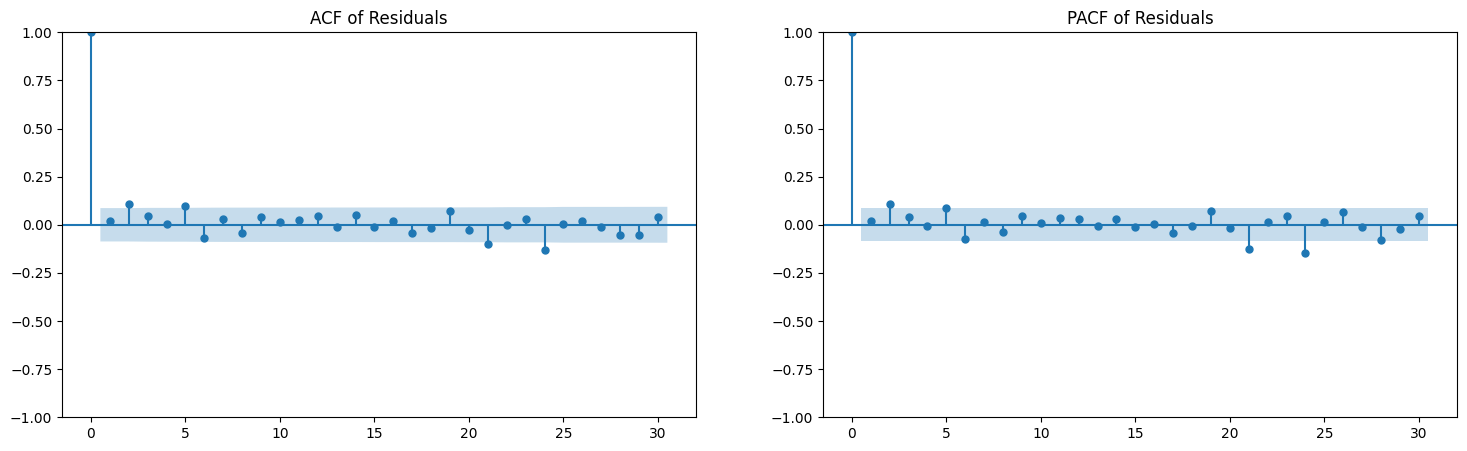


Variance Inflation Factor (VIF) Check (VIF < 5-10 là OK):
                     feature        VIF
5         Competitor Pricing  83.443226
4                      Price  83.388212
0   Weather Condition_Cloudy   2.627451
2    Weather Condition_Snowy   2.572556
3    Weather Condition_Sunny   2.496607
1    Weather Condition_Rainy   2.316372
8          Holiday/Promotion   1.023527
6                   Discount   1.015820
7            Demand Forecast   1.014038
9                        dow   1.011811
10                     month   1.002666


In [12]:
## Residual ~ white noise (Ljung–Box)
resid = result.resid
lb_test = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
print("\nLjung–Box Test (p-value > 0.05 là tốt):")
print(lb_test)
if all(lb_test['lb_pvalue'] > 0.05):
    print("-> Residuals gần giống White Noise. OK.")
else:
    print("-> Residuals CÓ CHỨA thông tin chưa được mô hình hóa (p-value < 0.05). Cần xem xét lại tham số hoặc biến exog.")

## ACF/PACF
plt.figure(figsize=(18, 5))
plt.subplot(121)
plot_acf(resid, lags=30, ax=plt.gca(), title='ACF of Residuals')
plt.subplot(122)
plot_pacf(resid, lags=30, ax=plt.gca(), title='PACF of Residuals')
plt.show()

## Kiểm tra Đa cộng tuyến (VIF)
def calculate_vif(X):
    # Dùng DataFrame của các biến ngoại sinh đã được xử lý (train_exog_df)
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    # Kiểm tra VIF
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

vif_results = calculate_vif(train_exog_df)
print("\nVariance Inflation Factor (VIF) Check (VIF < 5-10 là OK):")
print(vif_results)

 11. LƯU KẾT QUẢ (DELIVERABLES)

Đã tạo file: preds_sarimax_storeS001_prodP0001.csv


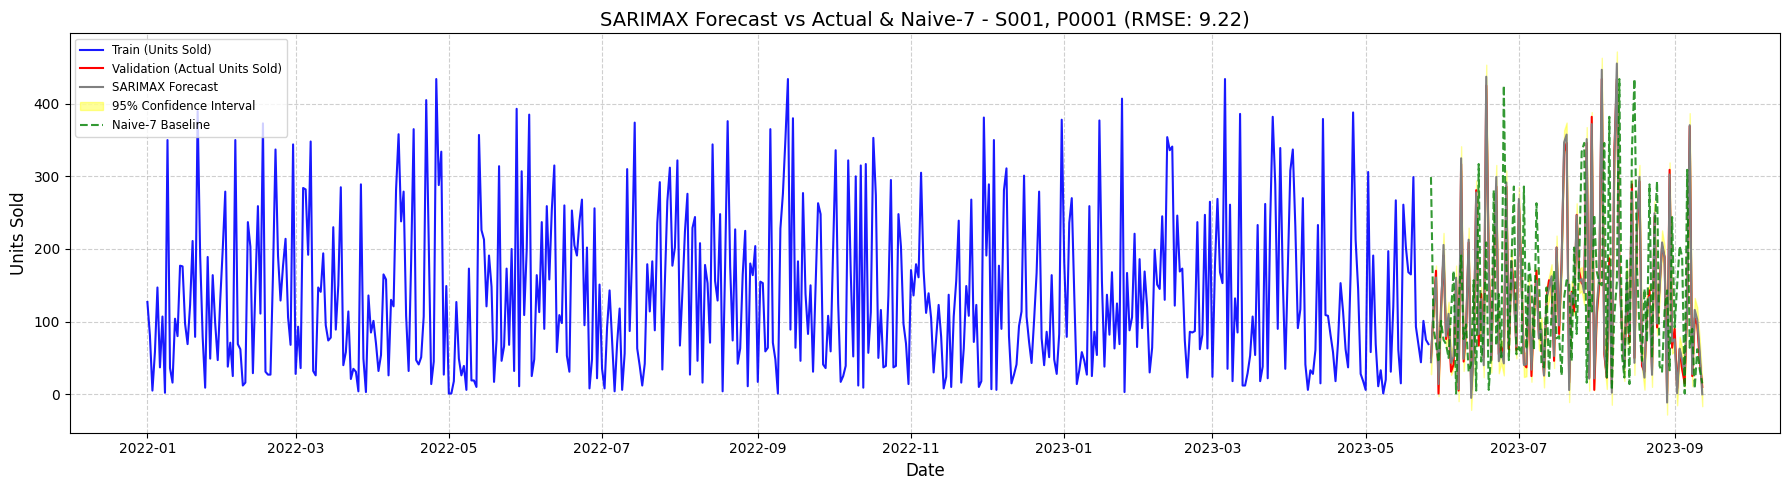

Đã tạo file báo cáo: SARIMAX_S001_P0001.md


In [18]:
## pred_sarimax_*.csv
output = pd.DataFrame({
    'date': val_data.index,
    'y_true': val_data['Units Sold'],
    'y_pred': pred_mean,
    'lo': pred_ci.iloc[:,0],
    'hi': pred_ci.iloc[:,1]
})
filename_csv = f'preds_sarimax_store{store}_prod{product}.csv'
output.to_csv(filename_csv, index=False)
print(f"Đã tạo file: {filename_csv}")

## plots/actual_vs_pred.png
plt.figure(figsize=(18, 5))
plt.plot(train_data.index, train_data['Units Sold'], label='Train (Units Sold)', color='blue', alpha=0.9, linewidth=1.5)
plt.plot(val_data.index, val_data['Units Sold'], label='Validation (Actual Units Sold)', color='red', linewidth=1.5)
plt.plot(val_data.index, pred_mean, label='SARIMAX Forecast', color='grey', linewidth=1.5)
plt.fill_between(val_data.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                 color='yellow', alpha=0.4, label='95% Confidence Interval')
plt.plot(val_data_for_metrics.index, val_data_for_metrics['Naive_7_pred'],
         label='Naive-7 Baseline', color='green', linestyle='--', alpha=0.8, linewidth=1.5)

plt.legend(loc='upper left', fontsize='small')
plt.title(f"SARIMAX Forecast vs Actual & Naive-7 - {store}, {product} (RMSE: {rmse_sarimax:.2f})", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Units Sold", fontsize=12)
plt.tight_layout()
plt.savefig(f'actual_vs_pred_store{store}_prod{product}_overview.png', dpi=300)
plt.show()

## report/SARIMAX_<store>_<prod>.md
report_content = rf"""# Báo Cáo Phân Tích Mô Hình SARIMAX
## Chuỗi: {store} - {product}
---
### 1. Cấu hình Mô hình Tối ưu
| Tham số | Giá trị | Ghi chú |
| :--- | :--- | :--- |
| Chuỗi dài | {len(data)} ngày | Yêu cầu $\ge 180$ ngày |
| SARIMA Order | {best_order} | (p, d, q) |
| Seasonal Order | {best_seasonal_order}_7 | (P, D, Q)_s với s=7 |
| Biến Ngoại sinh (Exog) | {train_exog_df.columns.tolist()} | Đã được Scale/Encode |
| ADF p-value (d) | {adf_result[1]:.4f} (d={d_term}) | Kiểm tra Tính dừng |

### 2. Đánh giá (Validation Set)
| Metric | SARIMAX | Naive-7 Baseline | So sánh tương đối | Kết luận |
| :--- | :--- | :--- | :--- | :--- |
| RMSE | {rmse_sarimax:.3f} | {rmse_naive:.3f} | Tỷ lệ: {rmse_ratio:.2f} | Yêu cầu $\le 0.85 \times \text{{RMSE Naive-7}}$? {"Đạt" if rmse_ratio <= 0.85 else "Không Đạt"} |
| WAPE | {wape_sarimax:.3%} | {wape_naive:.3%} | Cải thiện: {wape_improvement:.1%} | Kỳ vọng $\ge 10-20\%$ |

### 3. Kiểm tra Chẩn đoán (QC)
#### Ljung-Box Test (Kiểm tra White Noise của Residuals)
| Lags | p-value | Kết luận |
| :--- | :--- | :--- |
| 10 | {lb_test.loc[10, 'lb_pvalue']:.3f} | {"OK" if lb_test.loc[10, 'lb_pvalue'] > 0.05 else "Cần xem xét"} |
| 20 | {lb_test.loc[20, 'lb_pvalue']:.3f} | {"OK" if lb_test.loc[20, 'lb_pvalue'] > 0.05 else "Cần xem xét"} |

#### Đa cộng tuyến (VIF)
{vif_results.to_markdown(index=False, floatfmt=".2f")}
*Lưu ý: VIF >= 5 cần được xem xét loại bỏ hoặc kết hợp biến.*
"""
with open(f'SARIMAX_{store}_{product}.md', 'w') as f:
    f.write(report_content)
print(f"Đã tạo file báo cáo: SARIMAX_{store}_{product}.md")